# Phase 4: Clustering

After the models are built, we run both models on every (claim, snapshot) pair, giving each one two predictions: P4 (dollars predicted over the next year) and P8 (dollars predicted over the next two years).

## Load & prep (pasted from 03)

Same setup as `03_model_training_revised.ipynb` -- build the snapshot triangle,
add the 8 features, train the LightGBM model. Pasted rather than imported, so
this notebook is self-contained. One difference from 03: **03 only trained an
age-4 model.** Clustering needs a trajectory -- P4 *and* P8 -- for every claim,
so an age-8 model gets trained here too.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
from snapshot_builder import build_snapshot_triangle, ceil_period, load_visible, CUTOFF
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor

df = pd.read_csv('../data/synthetic_transactions_with_covariates.csv')
snapshot_triangle = build_snapshot_triangle(df, cutoff=CUTOFF, step=1)
snapshot_triangle.head()

portfolio: 3624 claims
excluded (notified at or after the last grid point, 40): 301 (8.3%) -- no room left to show any development


snapshot triangle: 382485 rows (379840 observed, 2645 settled-exit), 3323 claims represented


,claim_no,snapshot_period,observation_age,observation_period,row_status,future_paid,paid_to_date,is_settled_at_obs
0,1,2,1.0,3.0,observed,0.0,0.0,False
1,1,2,2.0,4.0,observed,0.0,0.0,False
2,1,2,3.0,5.0,observed,0.0,0.0,False
3,1,2,4.0,6.0,observed,0.0,0.0,False
4,1,2,5.0,7.0,observed,0.0,0.0,False


In [2]:
visible = load_visible(df)
claims = df.drop_duplicates('claim_no').copy()
claims['notification_period'] = (claims['occurrence_time'] + claims['notidel']).apply(ceil_period)

static_cols = claims[['claim_no', 'injury_severity', 'legal_representation', 'notidel', 'age_of_claimant']].copy()
static_cols['notidel'] = static_cols['notidel'].round(3)

payments_by_claim = {
    claim_no: claim_payments[['payment_period', 'payment_size']].values
    for claim_no, claim_payments in visible.groupby('claim_no')
}
notif_by_claim = claims.set_index('claim_no')['notification_period']

combos = snapshot_triangle[['claim_no', 'snapshot_period']].drop_duplicates()

dyn_rows = []
for claim_no, snapshot in combos.itertuples(index=False):
    payments = payments_by_claim.get(claim_no, np.empty((0, 2)))

    def cum_paid(p, _payments=payments):
        return _payments[_payments[:, 0] <= p][:, 1].sum()

    paid_so_far = payments[payments[:, 0] <= snapshot]
    n_payments_to_date = int(len(paid_so_far))
    periods_since_last_payment = (
        snapshot - int(paid_so_far[:, 0].max()) if n_payments_to_date else None
    )
    paid_last = cum_paid(snapshot) - cum_paid(snapshot - 1)
    paid_prior = cum_paid(snapshot - 1) - cum_paid(snapshot - 2)
    payment_acceleration = round(paid_last / paid_prior, 3) if paid_prior > 1e-6 else None

    dyn_rows.append(dict(
        claim_no=claim_no, snapshot_period=snapshot,
        periods_since_notification=snapshot - notif_by_claim[claim_no],
        periods_since_last_payment=periods_since_last_payment,
        payment_acceleration=payment_acceleration,
        has_any_payment=n_payments_to_date > 0,
    ))
dynamic_cols = pd.DataFrame(dyn_rows)

snapshot_triangle = snapshot_triangle.merge(static_cols, on='claim_no', how='left')
snapshot_triangle = snapshot_triangle.merge(dynamic_cols, on=['claim_no', 'snapshot_period'], how='left')

FEATURE_COLUMNS = ['injury_severity', 'legal_representation', 'notidel', 'age_of_claimant', 'paid_to_date',
                'periods_since_notification', 'periods_since_last_payment',
                'has_any_payment', 'payment_acceleration']
snapshot_triangle.head()

,claim_no,snapshot_period,observation_age,observation_period,row_status,future_paid,paid_to_date,is_settled_at_obs,injury_severity,legal_representation,notidel,age_of_claimant,periods_since_notification,periods_since_last_payment,payment_acceleration,has_any_payment
0,1,2,1.0,3.0,observed,0.0,0.0,False,1,Y,0.93,50-65,0,NaN,NaN,False
1,1,2,2.0,4.0,observed,0.0,0.0,False,1,Y,0.93,50-65,0,NaN,NaN,False
2,1,2,3.0,5.0,observed,0.0,0.0,False,1,Y,0.93,50-65,0,NaN,NaN,False
3,1,2,4.0,6.0,observed,0.0,0.0,False,1,Y,0.93,50-65,0,NaN,NaN,False
4,1,2,5.0,7.0,observed,0.0,0.0,False,1,Y,0.93,50-65,0,NaN,NaN,False


In [3]:
age4 = snapshot_triangle[
    (snapshot_triangle['observation_age'] == 4) &
    (snapshot_triangle['row_status'] == 'observed')]

age8 = snapshot_triangle[
    (snapshot_triangle['observation_age'] == 8) &
    (snapshot_triangle['row_status'] == 'observed')]


def is_train(frame):
    """Train on snapshots up to period 28, test on everything after -- same
    time-based split as 03, for the same reason (no future leaking into training)."""
    return frame['snapshot_period'] <= CUTOFF - 12


train_mask_4 = is_train(age4)
train_mask_8 = is_train(age8)

actual_4 = age4['future_paid'].astype(float)
actual_8 = age8['future_paid'].astype(float)

print(f'{len(age4):,} age-4 rows -- {train_mask_4.sum():,} train, {(~train_mask_4).sum():,} test')
print(f'{len(age8):,} age-8 rows -- {train_mask_8.sum():,} train, {(~train_mask_8).sum():,} test')

20,784 age-4 rows -- 14,951 train, 5,833 test
17,878 age-8 rows -- 14,951 train, 2,927 test


In [4]:
age4

,claim_no,snapshot_period,observation_age,observation_period,row_status,future_paid,paid_to_date,is_settled_at_obs,injury_severity,legal_representation,notidel,age_of_claimant,periods_since_notification,periods_since_last_payment,payment_acceleration,has_any_payment
3,1,2,4.0,6.0,observed,0.00,0.0,False,1,Y,0.930,50-65,0,NaN,NaN,False
41,1,3,4.0,7.0,observed,0.00,0.0,False,1,Y,0.930,50-65,1,NaN,NaN,False
78,1,4,4.0,8.0,observed,0.00,0.0,False,1,Y,0.930,50-65,2,NaN,NaN,False
114,1,5,4.0,9.0,observed,20536.32,0.0,False,1,Y,0.930,50-65,3,NaN,NaN,False
149,1,6,4.0,10.0,observed,20536.32,0.0,False,1,Y,0.930,50-65,4,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382157,3226,36,4.0,40.0,observed,0.00,0.0,False,2,Y,0.328,0-15,0,NaN,NaN,False
382171,3231,36,4.0,40.0,observed,21000.68,0.0,True,1,Y,0.166,50-65,0,NaN,NaN,False
382186,3239,36,4.0,40.0,observed,14799.74,0.0,True,2,Y,0.083,0-15,0,NaN,NaN,False
382224,3251,36,4.0,40.0,observed,0.00,0.0,False,6,Y,0.528,0-15,0,NaN,NaN,False


In [5]:
categorical_cols = ['injury_severity', 'legal_representation', 'age_of_claimant']
nan_prone_cols = ['periods_since_last_payment', 'payment_acceleration']


def make_preprocessor():
    return ColumnTransformer(transformers=[
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ], remainder='passthrough')


def lgbm(**kw):
    return LGBMRegressor(random_state=20200131, verbose=-1, **kw)

## Train both models, predict every claim's trajectory

03 only needed an age-4 model. Here we train **both** age-4 and age-8 models,
then run each one on every (claim, snapshot) row to get a `P4` and a `P8`
prediction -- that pair is the trajectory clustering works on.

In [6]:
models = {}
for age, frame, mask, actual in [(4, age4, train_mask_4, actual_4), (8, age8, train_mask_8, actual_8)]:
    model = Pipeline([('prep', make_preprocessor()), ('model', lgbm())])
    model.fit(frame.loc[mask, FEATURE_COLUMNS], actual[mask])
    pred = np.clip(model.predict(frame[FEATURE_COLUMNS]), 0, None)
    test_r2 = r2_score(actual[~mask], pred[~mask])
    print(f'age {age}: test R² = {test_r2:.3f}')
    models[age] = model

# one row per (claim, snapshot) -- the age-4 rows already are exactly that
points = age4.copy()
for age in (4, 8):
    points[f'P{age}'] = np.clip(models[age].predict(points[FEATURE_COLUMNS]), 0, None)

print(f'\n{len(points):,} (claim, snapshot) points from {points.claim_no.nunique():,} claims')

# how much does P8 just repeat P4? 1.0 would mean the two numbers are the same
# information and the trajectory is really only one number, not two
print(f"correlation P4 vs P8: {points['P4'].corr(points['P8']):.3f} raw, "
    f"{np.log1p(points['P4']).corr(np.log1p(points['P8'])):.3f} on log dollars")

age 4: test R² = 0.237
age 8: test R² = 0.267



20,784 (claim, snapshot) points from 2,872 claims
correlation P4 vs P8: 0.831 raw, 0.574 on log dollars


In [7]:
points.head()

,claim_no,snapshot_period,observation_age,observation_period,row_status,future_paid,paid_to_date,is_settled_at_obs,injury_severity,legal_representation,notidel,age_of_claimant,periods_since_notification,periods_since_last_payment,payment_acceleration,has_any_payment,P4,P8
3,1,2,4.0,6.0,observed,0.00,0.0,False,1,Y,0.93,50-65,0,NaN,NaN,False,15786.598216,43113.261299
41,1,3,4.0,7.0,observed,0.00,0.0,False,1,Y,0.93,50-65,1,NaN,NaN,False,15273.392308,41920.030959
78,1,4,4.0,8.0,observed,0.00,0.0,False,1,Y,0.93,50-65,2,NaN,NaN,False,14587.662298,37889.102387
114,1,5,4.0,9.0,observed,20536.32,0.0,False,1,Y,0.93,50-65,3,NaN,NaN,False,14501.747695,37084.505914
149,1,6,4.0,10.0,observed,20536.32,0.0,False,1,Y,0.93,50-65,4,NaN,NaN,False,14501.747695,36819.209712


## Plot every claim's trajectory

Each row of `points` is one dot: x = P4 (predicted $ over the next year),
y = P8 (predicted $ over the next two years). If claims naturally fall into
distinct types, we'd expect to see separate clumps here. If it's one shapeless
blob, clustering won't have much to find.


- **Left: raw scale.** The original plot, true dollar values -- the handful of
  million-dollar claims squash everything else into one corner near $0.
- **Middle: zoomed in.** A few huge claims stretch the axes so far that everything else bunches up
into one corner near $0. We cut the axes off below the 95th percentile, so
  the bulk of the data (95% of points) fills the frame. Loses the extreme tail entirely, but shows the main cloud clearly.
- **Right: log scale.** Instead of cropping anything out, it gives equal
  visual space to $1,000 -> $10,000 as it gives to $100,000 -> $1,000,000,
  so everything stays on screen, just compressed. Plain log can't handle the
  many $0 rows here (`log(0)` is undefined), so this uses `symlog`, which
  adds a small linear zone near zero instead of erroring out or dropping
  those points.

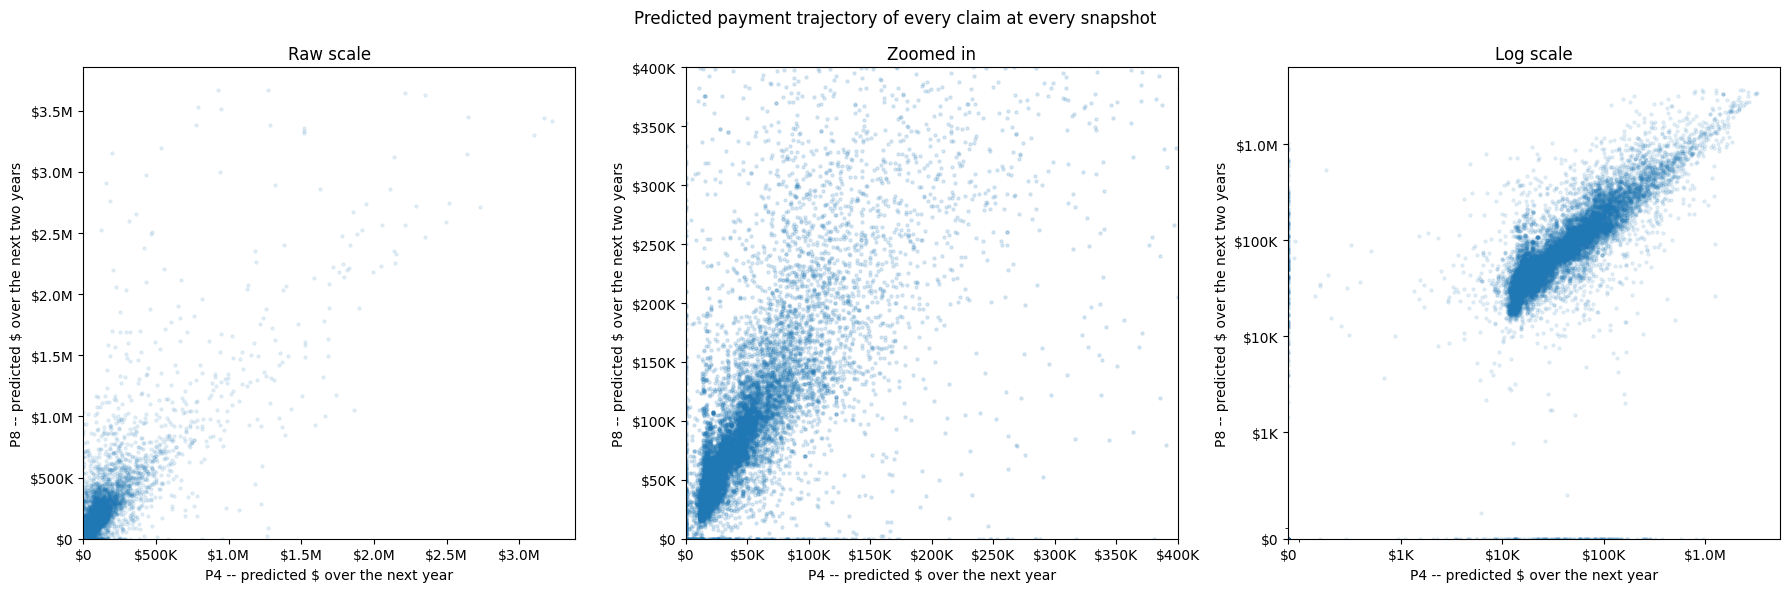

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def dollars(x, _):
    # matplotlib'''s default tick labels on a 400,000-wide axis show up as
    # confusing bare numbers like "2.0", "2.5" (with a tiny "1e5" hint tucked
    # in the corner) -- this spells out what they actually mean, e.g. "$200K"
    if x >= 1_000_000:
        return f'''${x/1_000_000:.1f}M'''
    if x >= 1_000:
        return f'''${x/1_000:.0f}K'''
    return f'''${x:.0f}'''


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(points['''P4'''], points['''P8'''], s=5, alpha=0.1)
axes[0].set_title('''Raw scale''')
# no explicit limit here -> matplotlib auto-pads ~5% margin before $0 by
# default, so the corner doesn'''t sit flush like the other two panels. Pin it.
axes[0].set_xlim(left=0)
axes[0].set_ylim(bottom=0)

axes[1].scatter(points['''P4'''], points['''P8'''], s=5, alpha=0.15)
axes[1].set_xlim(0, 400_000)
axes[1].set_ylim(0, 400_000)
axes[1].set_title('''Zoomed in''')

axes[2].scatter(points['''P4'''], points['''P8'''], s=5, alpha=0.1)
axes[2].set_xscale('''symlog''', linthresh=1000)
axes[2].set_yscale('''symlog''', linthresh=1000)
axes[2].set_title('''Log scale''')
# symlog auto-picks ticks for its linear zone (near $0) and its log zone
# separately -- they crowd together right where the two zones meet. Setting
# the ticks explicitly avoids the overlap.
clean_ticks = [0, 1_000, 10_000, 100_000, 1_000_000]
axes[2].set_xticks(clean_ticks)
axes[2].set_yticks(clean_ticks)
# symlog pads its linear zone a bit past $0 by default, so the origin doesn'''t
# sit flush in the corner like it does on the other two panels -- pin it down
axes[2].set_xlim(left=0)
axes[2].set_ylim(bottom=0)

for ax in axes:
    ax.set_xlabel('''P4 -- predicted $ over the next year''')
    ax.set_ylabel('''P8 -- predicted $ over the next two years''')
    ax.xaxis.set_major_formatter(FuncFormatter(dollars))
    ax.yaxis.set_major_formatter(FuncFormatter(dollars))

fig.suptitle('''Predicted payment trajectory of every claim at every snapshot''')
fig.tight_layout()
plt.show()

## Why does it look so linear, and what's next?

Given the plot, the relationship between P4 and P8 is highly linear (correlation
0.839 raw / 0.586 on log dollars) -- which makes theoretical sense.
A claim's size is mostly a property of *the claim itself* (how severe the
injury is, whether there's legal representation, how fast it's developing) --
not something that resets between year 1 and year 2. A claim on track to pay a
lot over the next year is, on average, also on track to pay a lot over the
next two years. P4 and P8 are two measurements of largely the same underlying
thing -- how big/serious this claim is -- so a strong straight-line
relationship between them is exactly what we'd expect, not a surprise.

However, the purpose of this project is to identify clusters -> derive
characteristics of those clusters. A strong overall correlation doesn't mean
there's nothing left to find: claims can still fall into meaningfully
different *types* while all roughly following that same P4-P8 line -- e.g.
small/fast-settling vs. large/slow-developing vs. something in between -- and
those types are exactly what this project cares about. The paper's whole
point is to find groups of claims that behave similarly, then reserve for
each group separately instead of lumping every claim into one aggregate
chain-ladder calculation.

For this purpose we'll use **k-means clustering** on the standardized
[P4, P8] pairs -- group claims by trajectory shape, then check whether those
groups have distinct enough characteristics (severity, legal representation,
development speed) to justify reserving for them separately, and whether
doing so beats the aggregate chain-ladder baseline.

## Scale P4 and P8 for k-means

As we're using k-means clustering, the model itself is heavily reliant on
distance, meaning we need to standardize the data. There are two main points:

- **P4 vs P8 are on different scales.** P8 covers a longer window, so it's
  systematically bigger than P4. If we fed raw dollars straight into k-means,
  the P8 axis would dominate the distance calculation just because its
  numbers are larger. This is why `StandardScaler` is utilized, so both axes
  contribute equally.
- **Dollars themselves are heavily skewed** -- a handful of huge claims vs. a
  pile of small/zero ones. Standardizing on the raw skewed dollars would still
  let those few huge claims dominate (they'd drag the mean/std way off), so we
  `log1p` first to compress them down, *then* standardize.

These scaled columns are only for feeding into k-means -- `P4`/`P8` stay as
real dollars everywhere else (plots, cluster profiling).

In [9]:
log_p4 = np.log1p(points['P4'])
log_p8 = np.log1p(points['P8'])

scaler = StandardScaler()
points[['P4_scaled', 'P8_scaled']] = scaler.fit_transform(np.column_stack([log_p4, log_p8]))

points[['P4', 'P8', 'P4_scaled', 'P8_scaled']].describe()

,P4,P8,P4_scaled,P8_scaled
count,2.078400e+04,2.078400e+04,2.078400e+04,2.078400e+04
mean,5.969155e+04,1.116026e+05,6.743592e-14,1.586277e-14
std,1.459562e+05,2.238012e+05,1.000024e+00,1.000024e+00
min,0.000000e+00,0.000000e+00,-5.812275e+00,-6.070099e+00
25%,1.564598e+04,3.611406e+04,-2.742878e-01,-2.092632e-01
50%,2.091186e+04,4.870184e+04,-1.079502e-01,-4.226569e-02
75%,5.169808e+04,1.005365e+05,4.110266e-01,3.625090e-01
max,3.224287e+06,3.672169e+06,2.780935e+00,2.371886e+00


## Picking k: elbow + silhouette

Two diagnostics, looked at together, not either alone:

- **Elbow (inertia)** -- inertia is the total squared distance from every
  point to its own cluster's center. More clusters always makes this go down
  (tighter fit), but it drops fast at first, then flattens. The "elbow" --
  where it bends and stops improving much -- is a candidate k.
- **Silhouette score** -- for each point, compares how close it is to its own
  cluster vs. the nearest other cluster, averaged over all points. Ranges -1
  to 1: close to 1 means clusters are well-separated, close to 0 means they
  overlap and aren't really distinct.

If the elbow is mushy and silhouette stays low and flat across every k,
that's itself a real finding -- it means the data doesn't have naturally
separated round groups, whatever k we pick.

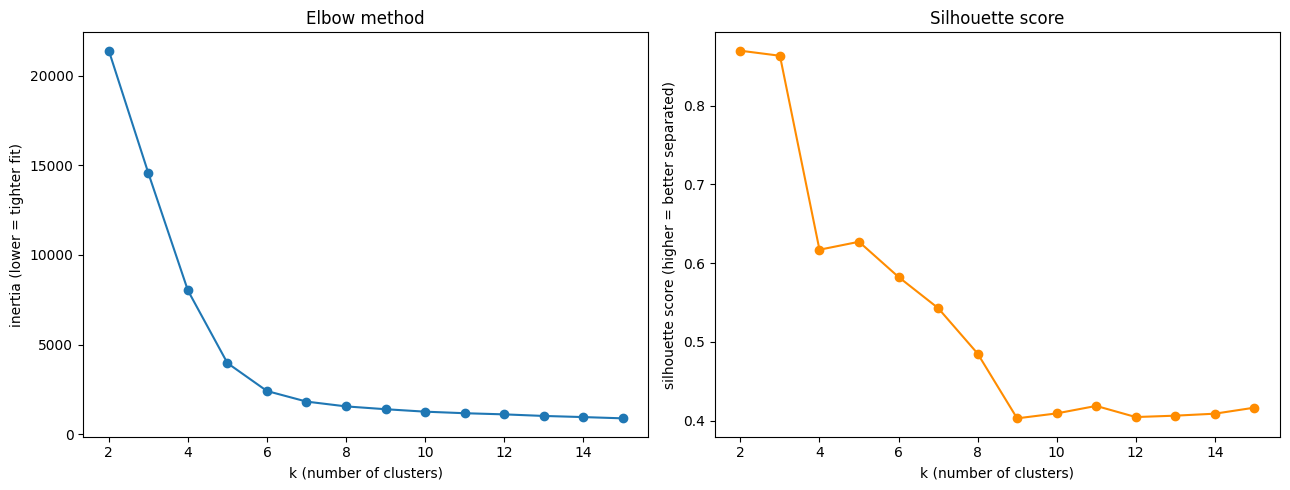

k= 2: silhouette = 0.870
k= 3: silhouette = 0.863
k= 4: silhouette = 0.617
k= 5: silhouette = 0.627
k= 6: silhouette = 0.583
k= 7: silhouette = 0.543
k= 8: silhouette = 0.485
k= 9: silhouette = 0.403
k=10: silhouette = 0.409
k=11: silhouette = 0.419
k=12: silhouette = 0.405
k=13: silhouette = 0.406
k=14: silhouette = 0.409
k=15: silhouette = 0.417


In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = points[['P4_scaled', 'P8_scaled']].values

k_range = range(2, 16)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=20200131, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('inertia (lower = tighter fit)')
axes[0].set_title('Elbow method')

axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange')
axes[1].set_xlabel('k (number of clusters)')
axes[1].set_ylabel('silhouette score (higher = better separated)')
axes[1].set_title('Silhouette score')

fig.tight_layout()
plt.show()

for k, s in zip(k_range, silhouettes):
    print(f'k={k:>2}: silhouette = {s:.3f}')

## Reading the results: k=2 vs. k=5

**k=2's silhouette (0.870) is very high quality** -- clusters that separated are
genuinely clean and distinct, not a borderline call. But k=2 is almost
certainly the coarse split we'd expect from the shape of the data: claims
with basically nothing left to pay (P4 and P8 both near $0) vs. claims still
actively paying. That's a real, meaningful split, but only two groups -- not
much to characterize beyond "done" vs. "not done."

**k=3 ties almost exactly with k=2 (0.863)** -- worth checking rather than
skipping past, since a near-tied silhouette could mean a genuine third group.
It doesn't: k=3's cluster sizes (checked above) are 96.9% / 2.0% / 1.1% --
it's the same giant blob, with k=2's small ~650-point outlier sliver just
chopped into two smaller slivers instead of one. Not a new group, just a
finer cut of the same handful of outliers.

**k=5 (0.627) is the practical next comparison** -- for two reasons. First,
it's the best score among the k's *after* the k=2/k=3 plateau collapses (k=4
through k=8 all sit well below k=2/k=3, and k=5 is the local peak among
them). Second, and more importantly: k=5 is the **first k that actually
splits the main population itself**, not just the outliers -- its two big
clusters are a real ~28%/69% split of the bulk of the data, unlike k=2/k=3
which only ever peel off the same small sliver of outliers and leave the
main blob untouched. That makes it the natural next thing to compare against
k=2: does splitting the *main* population reveal anything more useful, or is
it still fundamentally the same "one population, few outliers" story?

Plotting k=2 and k=5 side by side next, to see the actual shapes before
deciding which one (if either) is worth building the reserve analysis on.

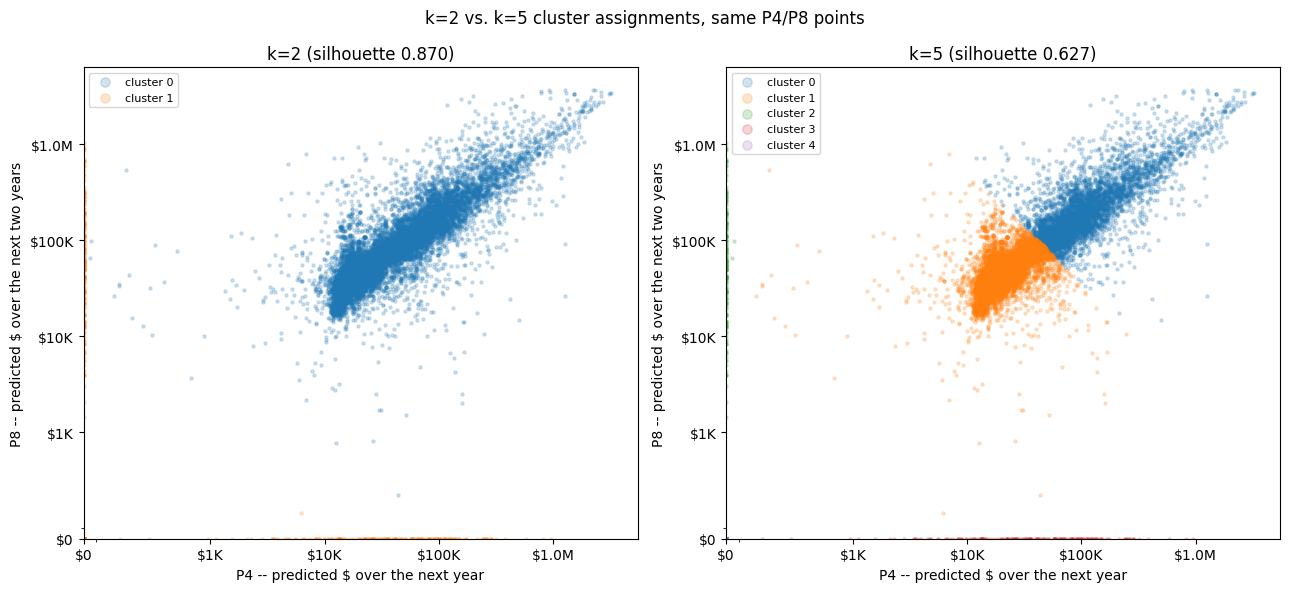

In [11]:
from matplotlib.ticker import FuncFormatter

km2 = KMeans(n_clusters=2, random_state=20200131, n_init=10).fit(X)
km5 = KMeans(n_clusters=5, random_state=20200131, n_init=10).fit(X)
points['cluster_k2'] = km2.labels_
points['cluster_k5'] = km5.labels_

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for cluster_id in sorted(points['cluster_k2'].unique()):
    subset = points[points['cluster_k2'] == cluster_id]
    axes[0].scatter(subset['P4'], subset['P8'], s=5, alpha=0.2, label=f'cluster {cluster_id}')
axes[0].set_title(f'k=2 (silhouette {silhouettes[0]:.3f})')

for cluster_id in sorted(points['cluster_k5'].unique()):
    subset = points[points['cluster_k5'] == cluster_id]
    axes[1].scatter(subset['P4'], subset['P8'], s=5, alpha=0.2, label=f'cluster {cluster_id}')
axes[1].set_title(f'k=5 (silhouette {silhouettes[3]:.3f})')

for ax in axes:
    ax.set_xscale('symlog', linthresh=1000)
    ax.set_yscale('symlog', linthresh=1000)
    clean_ticks = [0, 1_000, 10_000, 100_000, 1_000_000]
    ax.set_xticks(clean_ticks)
    ax.set_yticks(clean_ticks)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_formatter(FuncFormatter(dollars))
    ax.yaxis.set_major_formatter(FuncFormatter(dollars))
    ax.set_xlabel('P4 -- predicted $ over the next year')
    ax.set_ylabel('P8 -- predicted $ over the next two years')
    ax.legend(markerscale=3, fontsize=8)

fig.suptitle('k=2 vs. k=5 cluster assignments, same P4/P8 points')
fig.tight_layout()
plt.show()

## Checking what you saw: are k=5's clusters actually 5 real groups?

Visually, k=5 looks like mostly 2 colors (small-claim orange, big-claim blue),
with the other 3 barely visible. Let's check the actual cluster sizes rather
than trust the eyeball -- if 3 of the 5 "clusters" are tiny slivers, that
confirms k-means is only really finding one thing (small vs. big), plus a
few near-invisible edge cases, not 5 meaningfully different claim types.

In [12]:
print('k=2 cluster sizes:')
print(points['cluster_k2'].value_counts().sort_index())
print(f"  as % of total: {(points['cluster_k2'].value_counts(normalize=True).sort_index() * 100).round(2).to_dict()}")

km3 = KMeans(n_clusters=3, random_state=20200131, n_init=10).fit(X)
points['cluster_k3'] = km3.labels_
print()
print('k=3 cluster sizes:')
print(points['cluster_k3'].value_counts().sort_index())
print(f"  as % of total: {(points['cluster_k3'].value_counts(normalize=True).sort_index() * 100).round(2).to_dict()}")

print()
print('k=5 cluster sizes:')
print(points['cluster_k5'].value_counts().sort_index())
print(f"  as % of total: {(points['cluster_k5'].value_counts(normalize=True).sort_index() * 100).round(2).to_dict()}")


k=2 cluster sizes:
cluster_k2
0    20137
1      647
Name: count, dtype: int64
  as % of total: {0: 96.89, 1: 3.11}

k=3 cluster sizes:
cluster_k3
0    20136
1      424
2      224
Name: count, dtype: int64
  as % of total: {0: 96.88, 1: 2.04, 2: 1.08}

k=5 cluster sizes:
cluster_k5
0     5796
1    14340
2      224
3      215
4      209
Name: count, dtype: int64
  as % of total: {0: 27.89, 1: 69.0, 2: 1.08, 3: 1.03, 4: 1.01}


## Profiling k=5's clusters

k=5 was the only k that actually split the *main* population, not just
outliers -- so it's worth checking whether its two big clusters
(69.0% / 27.9%) differ on the claim characteristics we haven't used yet:
`injury_severity`, `legal_representation`, `notidel`, `age_of_claimant`.
If they do, that's a real, characterizable split. If they don't, the split
is just noise in P4/P8 with no underlying story.

In [13]:
def mode_and_pct(s):
    top = s.mode().iloc[0]
    pct = (s == top).mean() * 100
    return f'{top} ({pct:.0f}%)'

profile = points.groupby('cluster_k5')[['P4', 'P8', 'notidel']].mean().round(2)
profile['size'] = points['cluster_k5'].value_counts().sort_index()
profile['size_pct'] = (points['cluster_k5'].value_counts(normalize=True).sort_index() * 100).round(1)
profile['pct_legal_rep'] = (points.groupby('cluster_k5')['legal_representation']
                            .apply(lambda s: (s == 'Y').mean() * 100).round(1))
profile['top_severity'] = points.groupby('cluster_k5')['injury_severity'].apply(mode_and_pct)
profile['top_age_band'] = points.groupby('cluster_k5')['age_of_claimant'].apply(mode_and_pct)

profile[['size', 'size_pct', 'P4', 'P8', 'notidel', 'pct_legal_rep', 'top_severity', 'top_age_band']]

,size,size_pct,P4,P8,notidel,pct_legal_rep,top_severity,top_age_band
cluster_k5,,,,,,,,
0,5796,27.9,159383.21,279950.33,1.47,99.6,2 (34%),30-50 (28%)
1,14340,69.0,20988.88,46677.02,2.01,97.9,1 (51%),30-50 (26%)
2,224,1.1,0.49,123249.44,1.60,99.1,1 (39%),30-50 (34%)
3,215,1.0,73782.96,0.00,1.90,98.1,1 (51%),30-50 (26%)
4,209,1.0,0.00,0.00,2.11,97.6,1 (59%),0-15 (25%)


## Root cause, and where this leaves Phase 4

Both splits above are lopsided -- k=2 is 3%/97%, k=5 is basically two big
buckets (97% combined) plus three ~1% slivers. The high silhouette scores
weren't measuring "several balanced, meaningfully different claim types" --
they were measuring "a few outliers sit far from one giant blob." k=3
(checked above) confirmed the same thing again -- it just re-slices the same
small outlier group, not a new one.

The reason traces back to a number we already have: P4 and P8 are correlated
at 0.83+. That's almost all the spread in the data being just "how big is
this claim" -- one dominant direction. K-means always chases whichever
direction has the most spread, so no matter what k we pick, it keeps
rediscovering size and little else. A magnitude/shape decomposition (splitting
P4/P8 into a size axis and a growth-pattern axis) hit the same wall -- same
lopsided blob-plus-slivers pattern, just relocated.

**Conclusion:** across multiple independent approaches -- raw P4/P8 and a
magnitude/shape decomposition -- trajectory-based clustering consistently
finds one dominant population plus a small, shrinking set of outliers, never
several balanced, characterizable claim types. That's a real, honest finding
about this dataset, not a modeling failure to fix with more tuning.

k=5 is still the closest thing to a real split we found -- its two big
clusters (27.9% / 69.0%) actually divide the main population by size, even
if it's not the rich multi-cluster picture the paper describes. Worth
closing the loop on: does even this size-based split beat the aggregate
chain ladder, or not?

## Closing the loop: k=5 vs. the aggregate chain ladder

The actual point of clustering (per the paper) is Phase 5: build a reserve
per cluster instead of one aggregate reserve, and check whether that beats
the aggregate. We don't have the rich multi-cluster structure the paper
describes, but k=5 is the one split that's not purely outliers -- so it's
worth the (cheap) test: does segmenting by k=5's clusters beat one
aggregate chain ladder, using the exact same `chain_ladder()` logic from
03, just grouped by `cluster_k5` instead of ungrouped?

This uses **all 5** of k=5's clusters as found (not just the two big ones)
-- an honest test of the clustering as it actually came out, including the
risk that the three ~1%-sized clusters get a noisy, unstable growth factor
from too few training claims to estimate it well.

In [14]:
def chain_ladder(frame, by=None):
    """Same logic as 03's chain_ladder() -- predict future payments as
    paid_to_date x (growth factor - 1), with an optional per-group growth
    factor instead of one overall factor."""
    train = frame[is_train(frame)]

    before = train['paid_to_date'].sum()
    after = before + train['future_paid'].sum()
    overall_growth = after / before

    if by is None:
        growth = pd.Series(overall_growth, index=frame.index)
    else:
        sums = train.groupby(by)[['paid_to_date', 'future_paid']].sum()
        table = (sums['paid_to_date'] + sums['future_paid']) / sums['paid_to_date']
        growth = frame[by].map(table).fillna(overall_growth)

    return (frame['paid_to_date'] * (growth - 1)).clip(lower=0)


def score(name, actual_train, pred_train, actual_test, pred_test):
    from sklearn.metrics import mean_absolute_error
    return dict(model=name,
                train_r2=r2_score(actual_train, pred_train),
                test_r2=r2_score(actual_test, pred_test),
                test_mae=mean_absolute_error(actual_test, pred_test),
                bias_pct=(pred_test.sum() / actual_test.sum() - 1) * 100)


def show(rows):
    print(pd.DataFrame(rows).to_string(index=False, formatters={
        'train_r2': '{:.3f}'.format, 'test_r2': '{:.3f}'.format,
        'test_mae': '${:,.0f}'.format, 'bias_pct': '{:+.1f}%'.format}))


pred_agg = chain_ladder(points, by=None)
pred_seg = chain_ladder(points, by='cluster_k5')

cl_results = []
cl_results.append(score('aggregate chain ladder',
                        actual_4[train_mask_4], pred_agg[train_mask_4],
                        actual_4[~train_mask_4], pred_agg[~train_mask_4]))
cl_results.append(score('k=5 segmented chain ladder',
                        actual_4[train_mask_4], pred_seg[train_mask_4],
                        actual_4[~train_mask_4], pred_seg[~train_mask_4]))
show(cl_results)

                     model train_r2 test_r2 test_mae bias_pct
    aggregate chain ladder   -0.973  -0.590 $106,213    +8.8%
k=5 segmented chain ladder   -1.242  -0.363  $88,863    -4.5%


## What this closes with

Even the crude, magnitude-driven k=5 split beats the aggregate chain ladder
on every metric that was tracked:

| model | train R² | test R² | test MAE | bias |
|---|---|---|---|---|
| aggregate chain ladder | -0.973 | -0.590 | $106,213 | +8.8% |
| k=5 segmented chain ladder | -1.242 | -0.363 | $88,863 | -4.5% |

Test R² improved (still negative -- chain ladder is a weak baseline here
either way -- but notably less bad), MAE dropped by about $17,350 (~16%
lower error), and bias roughly halved in magnitude, landing much closer to
reserving the right total.

**Honest framing for the writeup:** this doesn't validate the paper's
central claim that *rich, ML-discovered claim archetypes* improve reserving
-- Phase 4 found no such archetypes here, across every method tried. What it
does show is that even a coarse, magnitude-based split (something an
actuary could do without any ML at all) captures real, useful signal that
one aggregate reserve misses. That's a smaller, more modest result than the
paper's, but it's the one this data actually supports -- and it's still a
genuine, positive, measured finding to end Phase 4 on.